# pertkit — Boundary Layers (Matched Asymptotic Expansions)

**Singular perturbation problems** arise when ε multiplies the *highest derivative*:

$$\varepsilon u'' + p(x)\,u' + q(x)\,u = f(x), \qquad u(0) = \alpha,\quad u(1) = \beta$$

Setting ε=0 drops the equation from 2nd to 1st order — you can no longer satisfy both BCs. The solution develops a **boundary layer**: a thin region of thickness O(ε) near one boundary where it rapidly adjusts.

## The method: three pieces

| Piece | Where valid | How found |
|:---|:---:|:---|
| **Outer** $u^\text{out}(x)$ | Away from layer | Solve reduced ODE (ε=0), far BC |
| **Inner** $U(\xi)$ | Inside layer | Stretch: $\xi = x/\varepsilon$, near BC |
| **Composite** | Everywhere | $u^\text{out} + U(\xi) - u^\text{match}$ |

The **matching condition** — $\lim_{\xi\to\infty} U(\xi) = u^\text{out}(0)$ — links the two.

**Layer location** is determined automatically from the sign of $p(x)$:
- $p(0) > 0$ → layer at $x=0$
- $p(1) < 0$ → layer at $x=1$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from sympy import *
from IPython.display import display, Math
from asymptotics import ODE

x_sym = symbols('x')

def numerical_bvp(rhs_fn, bc_fn, x_vals, y_init, tol=1e-10):
    """Helper: solve a BVP numerically."""
    sol = solve_bvp(rhs_fn, bc_fn, x_vals, y_init, tol=tol)
    return sol.sol(x_vals)[0]

def plot_comparison(x_vals, u_exact, u_comp, u_outer, eps_val, title,
                    layer='left'):
    # Broadcast scalars to arrays (e.g. outer=0 for right-layer case)
    u_comp  = np.broadcast_to(np.atleast_1d(u_comp),  x_vals.shape)
    u_outer = np.broadcast_to(np.atleast_1d(u_outer), x_vals.shape)
    """Standard comparison plot: exact vs composite vs outer."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(x_vals, u_exact, 'k-',  lw=2.5, label='Exact (numerical)', alpha=0.9)
    axes[0].plot(x_vals, u_comp,  'b--', lw=1.8, label='Composite')
    axes[0].plot(x_vals, u_outer, 'r:',  lw=1.8, label='Outer only')
    if layer == 'left':
        axes[0].axvspan(0, 5*eps_val, alpha=0.08, color='blue', label=f'Layer (5ε)')
    else:
        axes[0].axvspan(1-5*eps_val, 1, alpha=0.08, color='blue', label=f'Layer (5ε)')
    axes[0].set_title(title + f'  (ε={eps_val})')
    axes[0].set_xlabel('x'); axes[0].legend(fontsize=8)

    axes[1].semilogy(x_vals, np.abs(u_exact - u_comp)  + 1e-16, 'b--', label='Composite error')
    axes[1].semilogy(x_vals, np.abs(u_exact - u_outer) + 1e-16, 'r:',  label='Outer error')
    axes[1].set_title('Absolute error'); axes[1].set_xlabel('x'); axes[1].legend()

    plt.tight_layout(); plt.show()

---
## Example 1 — Left boundary layer (constant coefficients)

$$\varepsilon u'' + u' + u = 0, \qquad u(0)=0,\quad u(1)=1$$

Here $p(x) = 1 > 0$, so the layer is at $x=0$. The stretched coordinate is $\xi = x/\varepsilon$.

In [2]:
eq1 = ODE(
    "eps*u'' + u' + u",
    small_param="eps",
    conditions=["u(0) = 0", "u(1) = 1"],
)
sol1 = eq1.expand_boundary_layer()
sol1.show()

  ℹ️  dependent = 'u' (inferred from conditions), independent = 'x' (inferred from equation)
     To override: ODE(..., dependent='u', independent='x')


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

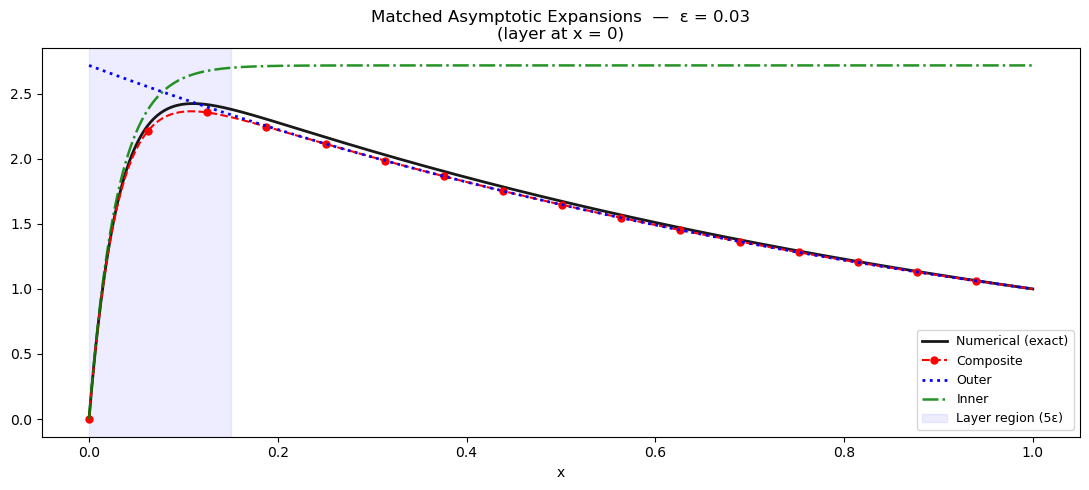

In [3]:
sol1.compare_numeric(eps = 0.03, problem=eq1,plot_range=[0,1]);

In [6]:
sol1.to_latex(show_orders='False')

% Matched asymptotic expansions

% Layer location: x = 0

% Stretched coordinate: xi = (x - layer) / eps



% Outer solution

\begin{align}
  u^{\text{out}}(x) &= e^{1 - x}
\end{align}


% Inner solution

\begin{align}
  U(\xi) &= e - e^{1 - \xi}
\end{align}


% Matching value: e



% Composite solution (Van Dyke rule)

\begin{align}
  u^{\text{comp}}(x,\varepsilon) &= \left(1 - e^{\frac{x \left(\varepsilon - 1\right)}{\varepsilon}}\right) e^{1 - x}
\end{align}


'% Matched asymptotic expansions\n\n% Layer location: x = 0\n\n% Stretched coordinate: xi = (x - layer) / eps\n\n\n\n% Outer solution\n\n\\begin{align}\n  u^{\\text{out}}(x) &= e^{1 - x}\n\\end{align}\n\n\n% Inner solution\n\n\\begin{align}\n  U(\\xi) &= e - e^{1 - \\xi}\n\\end{align}\n\n\n% Matching value: e\n\n\n\n% Composite solution (Van Dyke rule)\n\n\\begin{align}\n  u^{\\text{comp}}(x,\\varepsilon) &= \\left(1 - e^{\\frac{x \\left(\\varepsilon - 1\\right)}{\\varepsilon}}\\right) e^{1 - x}\n\\end{align}'

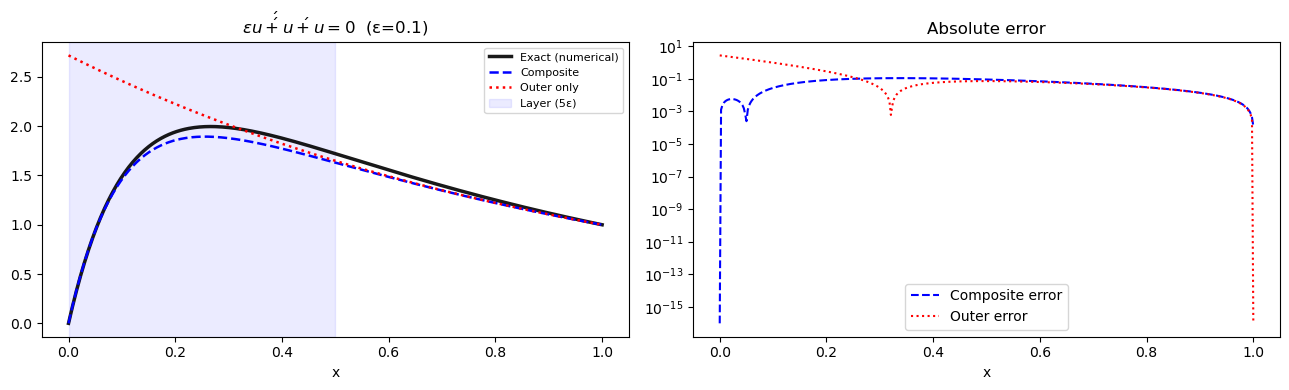

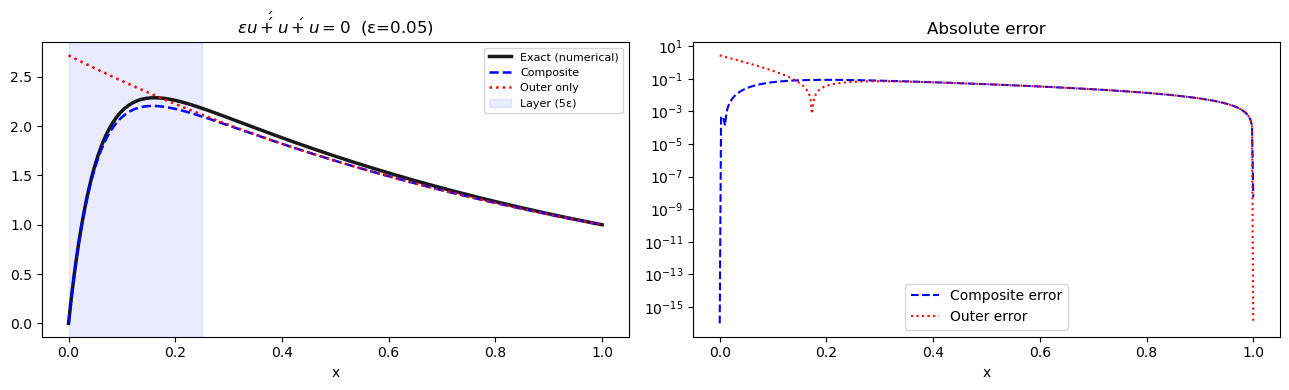

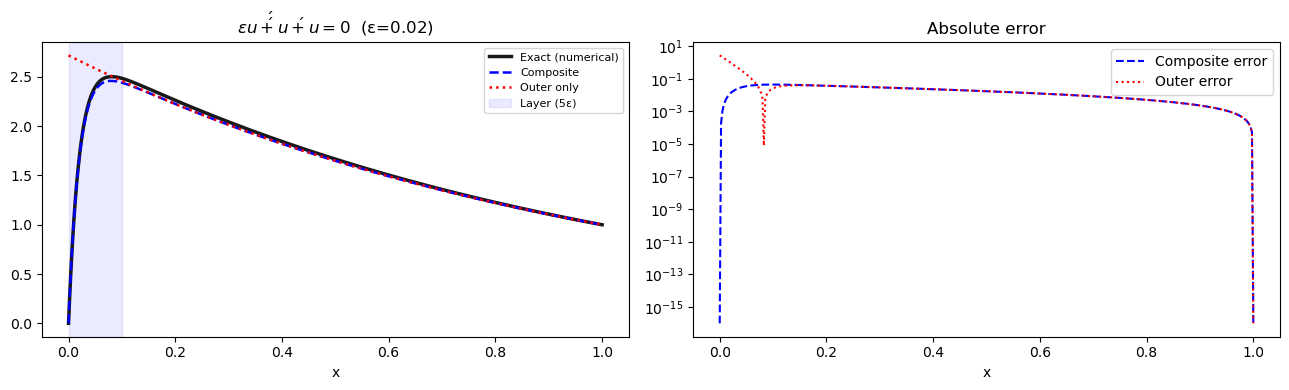

In [5]:
eps_sym = sol1.small_param

for eps_val in [0.1, 0.05, 0.02]:
    x_vals = np.linspace(0, 1, 400)
    comp_fn  = lambdify(x_sym, sol1.composite.subs(eps_sym, eps_val),  'numpy')
    outer_fn = lambdify(x_sym, sol1.outer.subs(eps_sym, eps_val),       'numpy')

    def rhs1(x, y): return [y[1], (-y[1] - y[0]) / eps_val]
    def bc1(ya, yb): return [ya[0], yb[0] - 1]
    y0 = np.zeros((2, x_vals.size)); y0[0] = x_vals
    u_exact = numerical_bvp(rhs1, bc1, x_vals, y0)

    plot_comparison(x_vals, u_exact, comp_fn(x_vals), outer_fn(x_vals),
                    eps_val, r'$\varepsilon u\'\' + u\' + u = 0$', layer='left')

---
## Example 2 — Right boundary layer

$$\varepsilon u'' - u' + u = 0, \qquad u(0)=0,\quad u(1)=1$$

Now $p(x) = -1 < 0$ at $x=1$, so the layer is at $x=1$. The stretched coordinate is $\xi = (1-x)/\varepsilon$.

In [6]:
eq2 = ODE(
    "eps*u'' - u' + u",
    dependent="u", small_param="eps", independent="x",
    conditions=["u(0) = 0", "u(1) = 1"],
)
sol2 = eq2.expand_boundary_layer()
sol2.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

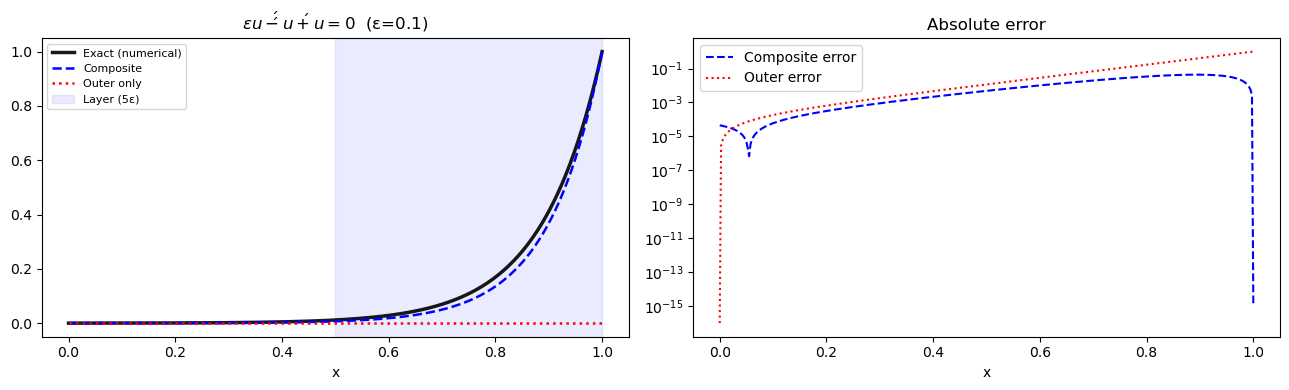

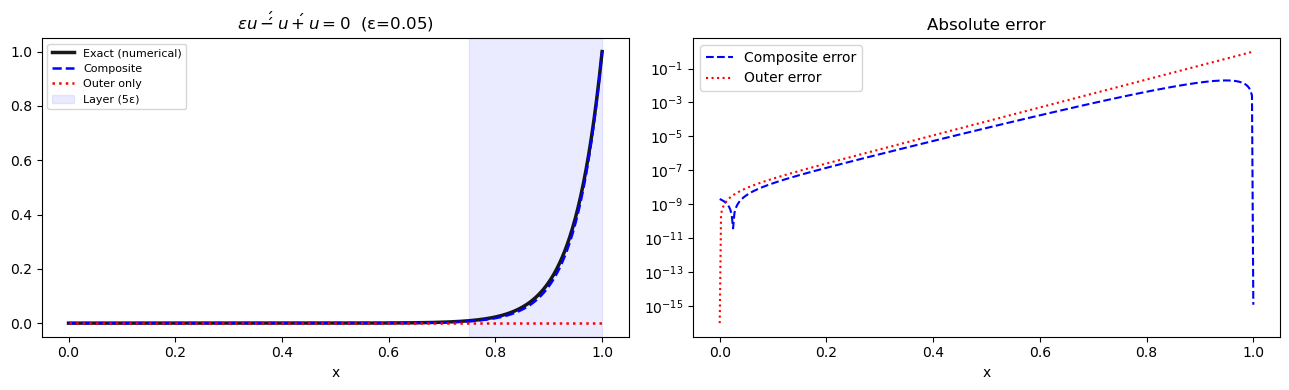

In [7]:
eps_sym2 = sol2.small_param

for eps_val in [0.1, 0.05]:
    x_vals   = np.linspace(0, 1, 400)
    comp_fn  = lambdify(x_sym, sol2.composite.subs(eps_sym2, eps_val), 'numpy')
    outer_fn = lambdify(x_sym, sol2.outer.subs(eps_sym2, eps_val),      'numpy')

    def rhs2(x, y): return [y[1], (y[1] - y[0]) / eps_val]
    def bc2(ya, yb): return [ya[0], yb[0] - 1]
    y0 = np.zeros((2, x_vals.size)); y0[0] = 1 - x_vals
    u_exact = numerical_bvp(rhs2, bc2, x_vals, y0)

    plot_comparison(x_vals, u_exact, comp_fn(x_vals), outer_fn(x_vals),
                    eps_val, r'$\varepsilon u\'\' - u\' + u = 0$', layer='right')

---
## Example 3 — Variable coefficients

$$\varepsilon u'' + (1+x)\,u' - u = 0, \qquad u(0)=1,\quad u(1)=2$$

$p(x) = 1+x > 0$ everywhere, so the layer is at $x=0$.

The outer ODE is $(1+x)\,u' - u = 0$, a separable equation with solution $u^\text{out} = x+1$.

Since $u^\text{out}(0) = 1 = u(0)$, the outer solution already satisfies the near BC — there is **no boundary layer correction** needed! The outer solution is uniformly valid.

In [8]:
eq3 = ODE(
    "eps*u'' + (1+x)*u' - u",
    dependent="u", small_param="eps", independent="x",
    conditions=["u(0) = 1", "u(1) = 2"],
)
sol3 = eq3.expand_boundary_layer()
sol3.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

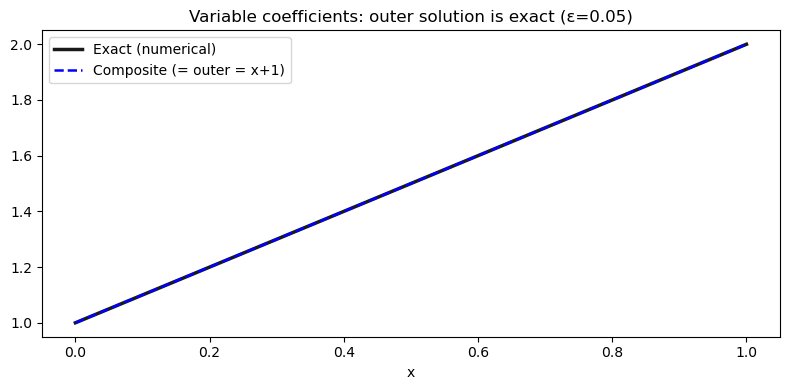

Max error: 4.44e-16
The outer solution x+1 satisfies u(0)=1 already — no layer correction needed.


In [9]:
eps_val  = 0.05
x_vals   = np.linspace(0, 1, 400)
eps_sym3 = sol3.small_param

comp_fn  = lambdify(x_sym, sol3.composite.subs(eps_sym3, eps_val), 'numpy')
outer_fn = lambdify(x_sym, sol3.outer.subs(eps_sym3, eps_val),      'numpy')

def rhs3(x, y): return [y[1], (y[0] - (1+x)*y[1]) / eps_val]
def bc3(ya, yb): return [ya[0] - 1, yb[0] - 2]
y0 = np.zeros((2, x_vals.size)); y0[0] = 1 + x_vals
u_exact = numerical_bvp(rhs3, bc3, x_vals, y0)

plt.figure(figsize=(8, 4))
plt.plot(x_vals, u_exact,       'k-',  lw=2.5, label='Exact (numerical)', alpha=0.9)
plt.plot(x_vals, comp_fn(x_vals), 'b--', lw=1.8, label=f'Composite (= outer = x+1)')
plt.title(f'Variable coefficients: outer solution is exact (ε={eps_val})')
plt.xlabel('x'); plt.legend()
plt.tight_layout(); plt.show()

print(f'Max error: {np.max(np.abs(comp_fn(x_vals) - u_exact)):.2e}')
print('The outer solution x+1 satisfies u(0)=1 already — no layer correction needed.')

---
## Example 4 — No reaction term: pure advection-diffusion

$$\varepsilon u'' + u' = 0, \qquad u(0)=0,\quad u(1)=1$$

This is the simplest possible case — pure advection-diffusion with no reaction. The exact solution is:
$$u(x) = \frac{1 - e^{-x/\varepsilon}}{1 - e^{-1/\varepsilon}}$$

The composite solution: $u^\text{comp} = 1 - e^{-x/\varepsilon}$ (the outer is just 1).

In [10]:
eq4 = ODE(
    "eps*u'' + u'",
    dependent="u", small_param="eps", independent="x",
    conditions=["u(0) = 0", "u(1) = 1"],
)
sol4 = eq4.expand_boundary_layer()
sol4.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

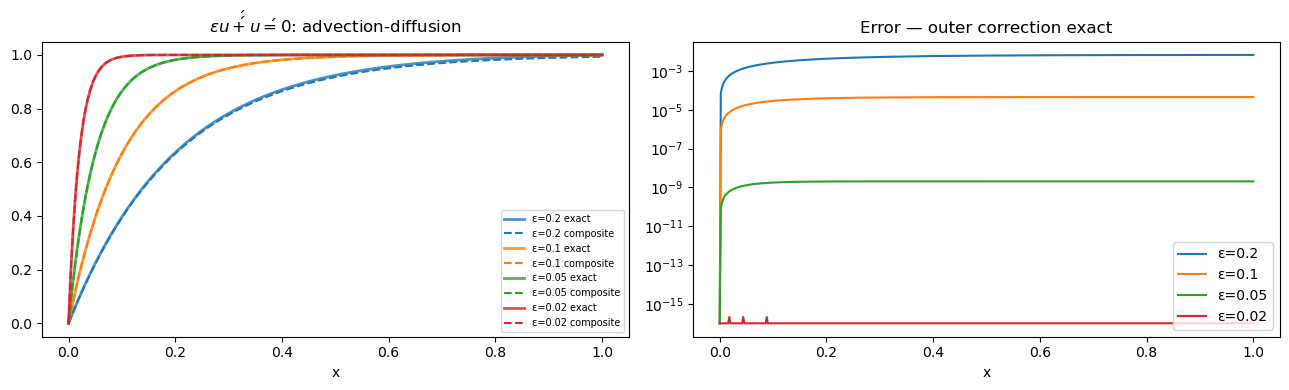

In [12]:
eps_sym4 = sol4.small_param
eps_vals = [0.2, 0.1, 0.05, 0.02]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x_dense = np.linspace(0, 1, 500)

for eps_val, color in zip(eps_vals, ['C0','C1','C2','C3']):
    # Exact: (1 - exp(-x/eps)) / (1 - exp(-1/eps))
    u_exact = (1 - np.exp(-x_dense/eps_val)) / (1 - np.exp(-1/eps_val))

    comp_fn = lambdify(x_sym, sol4.composite.subs(eps_sym4, eps_val), 'numpy')
    u_comp  = comp_fn(x_dense)

    axes[0].plot(x_dense, u_exact, '-',  color=color, lw=2,   alpha=0.8, label=f'ε={eps_val} exact')
    axes[0].plot(x_dense, u_comp,  '--', color=color, lw=1.5, label=f'ε={eps_val} composite')
    axes[1].semilogy(x_dense, np.abs(u_exact - u_comp) + 1e-16,
                     color=color, label=f'ε={eps_val}')

axes[0].set_title(r'$\varepsilon u\'\' + u\' = 0$: advection-diffusion')
axes[0].set_xlabel('x'); axes[0].legend(fontsize=7)
axes[1].set_title('Error — outer correction exact'); axes[1].set_xlabel('x'); axes[1].legend()
plt.tight_layout(); plt.show()

# display(Math(r'u^{\text{comp}} = 1 - e^{-x/\varepsilon} \approx \frac{1 - e^{-x/\varepsilon}}{1 - e^{-1/\varepsilon}}
#              \text{ (error } O(e^{-1/\varepsilon}) \text{)}'))

---
## Example 5 — Stronger damping

$$\varepsilon u'' + 2u' + u = 0, \qquad u(0)=0,\quad u(1)=1$$

The inner ODE now involves $p(0)=2$, giving a faster-decaying inner layer $e^{-2\xi}$.

In [13]:
eq5 = ODE(
    "eps*u'' + 2*u' + u",
    dependent="u", small_param="eps", independent="x",
    conditions=["u(0) = 0", "u(1) = 1"],
)
sol5 = eq5.expand_boundary_layer()
sol5.show()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

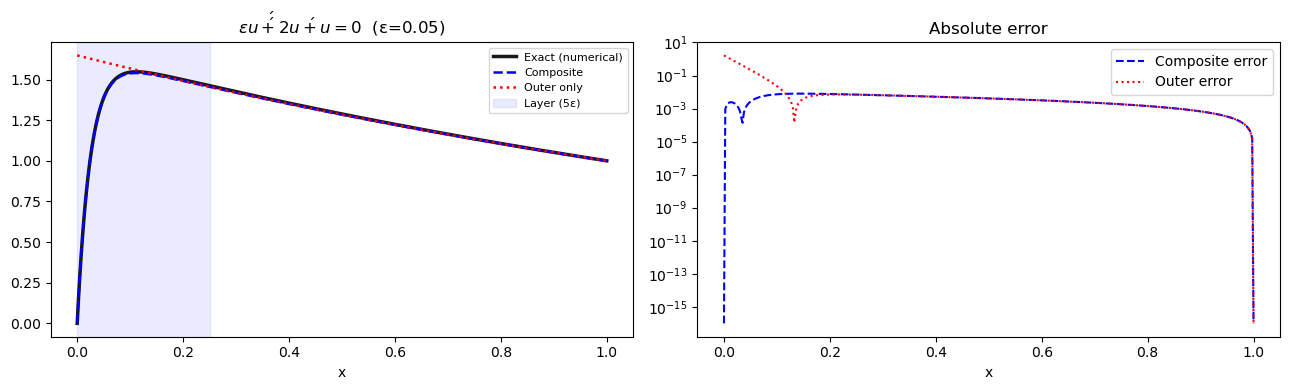

<IPython.core.display.Math object>

In [14]:
eps_sym5 = sol5.small_param
eps_val  = 0.05
x_vals   = np.linspace(0, 1, 400)

comp_fn  = lambdify(x_sym, sol5.composite.subs(eps_sym5, eps_val), 'numpy')
outer_fn = lambdify(x_sym, sol5.outer.subs(eps_sym5, eps_val),      'numpy')

def rhs5(x, y): return [y[1], (-2*y[1] - y[0]) / eps_val]
def bc5(ya, yb): return [ya[0], yb[0] - 1]
y0 = np.zeros((2, x_vals.size)); y0[0] = x_vals
u_exact = numerical_bvp(rhs5, bc5, x_vals, y0)

plot_comparison(x_vals, u_exact, comp_fn(x_vals), outer_fn(x_vals),
                eps_val, r'$\varepsilon u\'\' + 2u\' + u = 0$', layer='left')

display(Math(
    r'\text{Inner: } U(\xi) = ' + latex(sol5.inner)
    + r'\quad (\text{decays as } e^{-2\xi}\text{ — twice as fast as Example 1})'
))

---
## Layer thickness: effect of ε

The boundary layer has thickness O(ε). As ε → 0, the layer gets thinner and the gradient steeper.

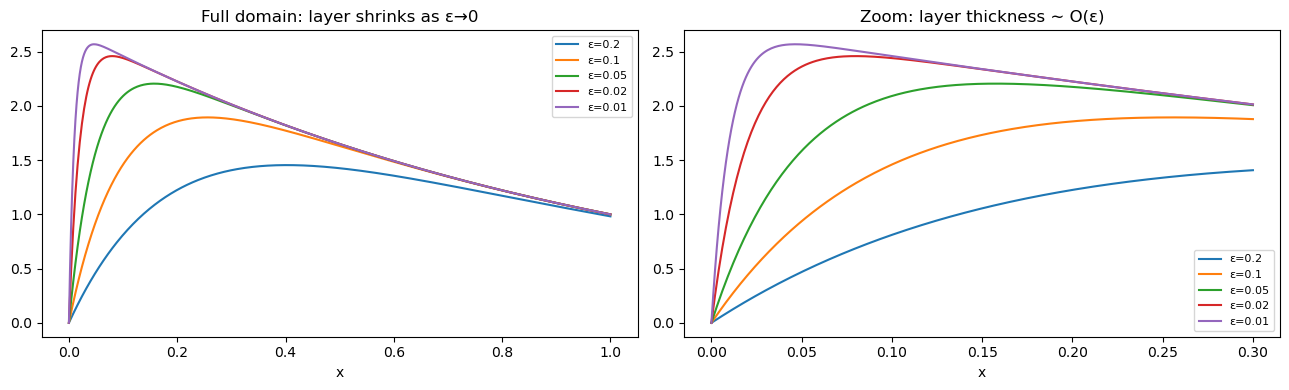

In [15]:
# Show how layer thickness scales with eps
eq_demo = ODE(
    "eps*u'' + u' + u",
    dependent="u", small_param="eps", independent="x",
    conditions=["u(0) = 0", "u(1) = 1"],
)
sol_demo = eq_demo.expand_boundary_layer()
eps_demo = sol_demo.small_param

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x_full = np.linspace(0, 1, 500)
x_zoom = np.linspace(0, 0.3, 300)  # zoom into layer region

for eps_val, color in zip([0.2, 0.1, 0.05, 0.02, 0.01], ['C0','C1','C2','C3','C4']):
    comp_fn = lambdify(x_sym, sol_demo.composite.subs(eps_demo, eps_val), 'numpy')
    axes[0].plot(x_full, comp_fn(x_full), color=color, lw=1.5, label=f'ε={eps_val}')
    axes[1].plot(x_zoom, comp_fn(x_zoom), color=color, lw=1.5, label=f'ε={eps_val}')

axes[0].set_title('Full domain: layer shrinks as ε→0')
axes[0].set_xlabel('x'); axes[0].legend(fontsize=8)
axes[1].set_title('Zoom: layer thickness ∼ O(ε)')
axes[1].set_xlabel('x'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## API quick reference

```python
from pertkit import ODE

eq  = ODE("eps*u'' + p(x)*u' + q(x)*u",
          dependent="u", small_param="eps", independent="x",
          conditions=["u(0) = alpha", "u(1) = beta"])

sol = eq.expand_boundary_layer()   # order=0 (leading order)

# Display — shows outer, inner, composite separately
sol.show()

# Access results
sol.layer_location   # 'x = 0' or 'x = 1' — auto-detected
sol.outer            # u_out(x) — outer solution
sol.inner            # U(ξ) — inner in stretched coordinate
sol.inner_xi         # u_in(x) — inner in original x
sol.match            # matching constant
sol.composite        # u_out + u_in - match
sol.outer_ode        # the reduced outer ODE
sol.inner_ode        # the inner ODE in ξ
sol.layer_var        # the ξ symbol
```

**Requirements:**
- 2nd-order ODE with ε multiplying u''
- BVP with conditions at two distinct points
- p(x) must have definite sign at one boundary:
  - p(0) > 0 → layer at x=0
  - p(1) < 0 → layer at x=1

**Variable coefficients** are fully supported — pertkit uses SymPy's dsolve on the outer ODE.